In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline
import seaborn as sns
from sklearn.impute import SimpleImputer

In [13]:
df=pd.read_csv("/content/arrhythmia.data",header=None)

In [14]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


#preprocessing

In [15]:

df.shape

(452, 280)

In [16]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,...,452.000000,452.000000,452.000000,452.000000,452.0,452.000000,452.000000,452.000000,452.000000,452.000000
mean,46.471239,0.550885,166.188053,68.170354,88.920354,155.152655,367.207965,169.949115,90.004425,33.676991,...,-0.278982,9.048009,-1.457301,0.003982,0.0,0.514823,1.222345,19.326106,29.473230,3.880531
std,16.466631,0.497955,37.170340,16.590803,15.364394,44.842283,33.385421,35.633072,25.826643,45.431434,...,0.548876,3.472862,2.002430,0.050118,0.0,0.347531,1.426052,13.503922,18.493927,4.407097
min,0.000000,0.000000,105.000000,6.000000,55.000000,0.000000,232.000000,108.000000,0.000000,-172.000000,...,-4.100000,0.000000,-28.600000,0.000000,0.0,-0.800000,-6.000000,-44.200000,-38.600000,1.000000
25%,36.000000,0.000000,160.000000,59.000000,80.000000,142.000000,350.000000,148.000000,79.000000,3.750000,...,-0.425000,6.600000,-2.100000,0.000000,0.0,0.400000,0.500000,11.450000,17.550000,1.000000
50%,47.000000,1.000000,164.000000,68.000000,86.000000,157.000000,367.000000,162.000000,91.000000,40.000000,...,0.000000,8.800000,-1.100000,0.000000,0.0,0.500000,1.350000,18.100000,27.900000,1.000000
75%,58.000000,1.000000,170.000000,79.000000,94.000000,175.000000,384.000000,179.000000,102.000000,66.000000,...,0.000000,11.200000,0.000000,0.000000,0.0,0.700000,2.100000,25.825000,41.125000,6.000000
max,83.000000,1.000000,780.000000,176.000000,188.000000,524.000000,509.000000,381.000000,205.000000,169.000000,...,0.000000,23.600000,0.000000,0.800000,0.0,2.400000,6.000000,88.800000,115.900000,16.000000


In [18]:
null_values=pd.isnull(df).sum().sum() # checking null values
print("null values :-",null_values)

null values :- 0


In [21]:
df.sample(3)

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
282,57,0,175,81,80,163,364,169,118,8,...,0.0,5.3,0.0,0.0,0.0,0.4,1.5,12.7,26.2,1
137,47,0,162,74,102,126,357,135,83,55,...,0.0,4.5,-1.5,0.0,0.0,0.6,1.2,8.1,16.5,10
315,57,0,170,65,77,160,359,141,100,68,...,-0.7,8.5,-1.2,0.0,0.0,0.8,0.6,14.3,17.4,1


In [23]:
# Count number of '?' in the entire dataset
num_question_marks = (df == '?').sum().sum()
print("Number of '?' in dataset:", num_question_marks)

Number of '?' in dataset: 408


In [24]:
df = df.replace('?', np.nan) #Replacing ? with np.nan value-



visualizing missing values

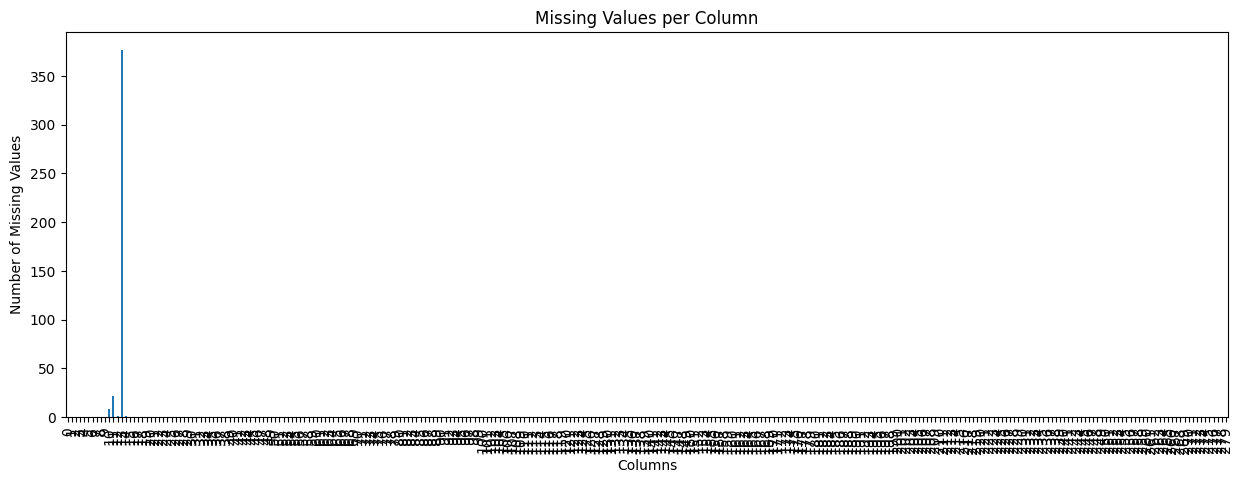

In [25]:
import matplotlib.pyplot as plt

# Count missing values per column
missing_counts = df.isnull().sum()

# Plot all columns
plt.figure(figsize=(15,5))
missing_counts.plot(kind='bar')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.show()

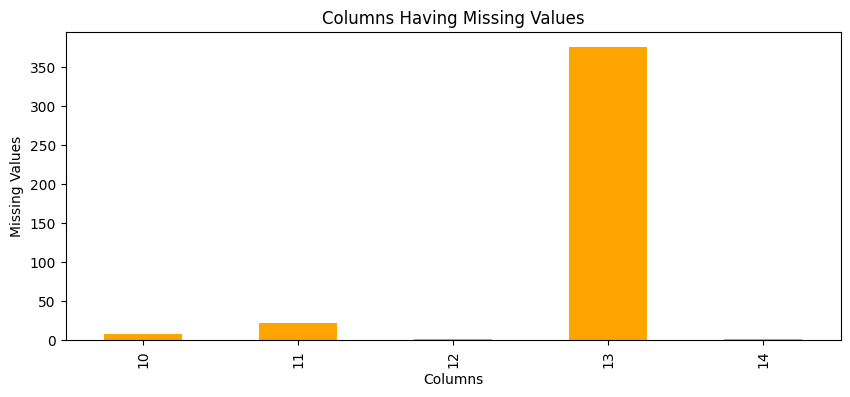

In [26]:
#Plot only columns with missing values
missing_cols = missing_counts[missing_counts > 0]

plt.figure(figsize=(10,4))
missing_cols.plot(kind='bar', color='orange')
plt.xlabel('Columns')
plt.ylabel('Missing Values')
plt.title('Columns Having Missing Values')
plt.show()

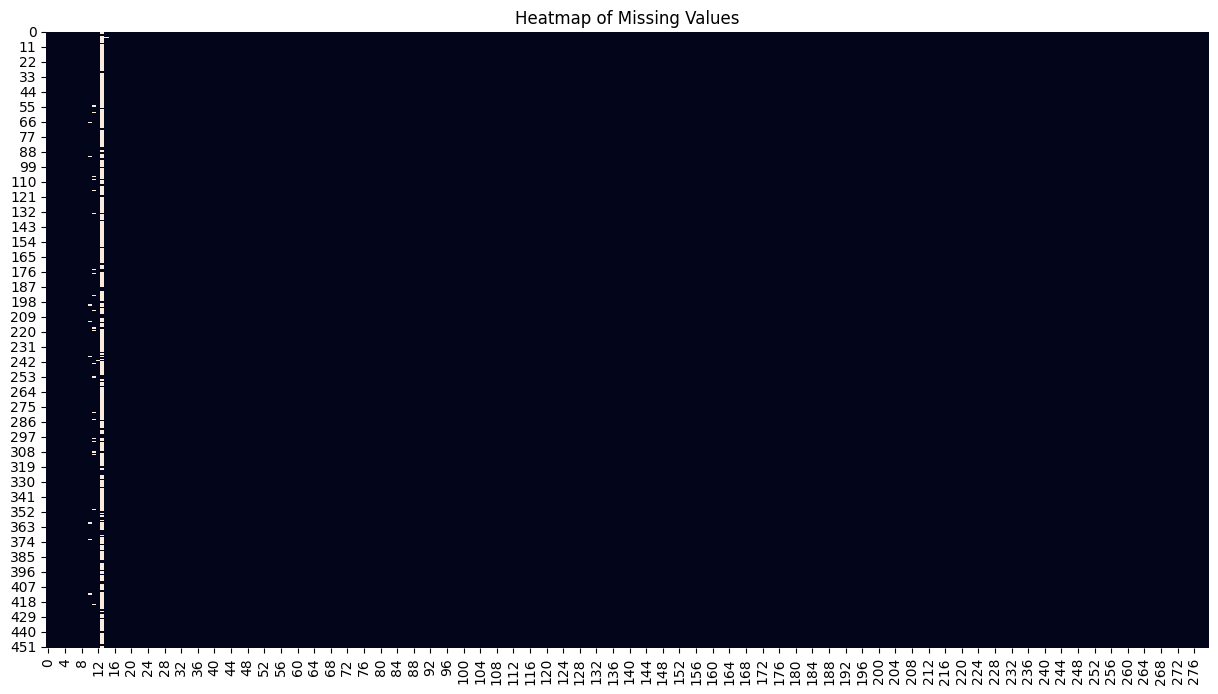

In [27]:
#Using heatmap for missing values
import seaborn as sns

plt.figure(figsize=(15,8))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Heatmap of Missing Values')
plt.show()

In [28]:
#as so many mising values are in column 13 better to remove that
df.drop(columns = 13, inplace=True)

In [29]:
#Imputation mising values wth mean

# make new columns indicating what will be imputed
new_df = df.copy()
cols_with_missing = (col for col in new_df.columns
                                 if new_df[col].isnull().any())
for col in cols_with_missing:
    new_df[col] = new_df[col].isnull()



my_imputer = SimpleImputer()
new_df = pd.DataFrame(my_imputer.fit_transform(new_df))
new_df.columns = df.columns

In [30]:
new_df.head()

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75.0,0.0,190.0,80.0,91.0,193.0,371.0,174.0,121.0,-16.0,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8.0
1,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6.0
2,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10.0
3,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1.0
4,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7.0


In [34]:
# Basic info columns
basic_cols = ["Age","Sex","Height","Weight","QRS_Dur","P-R_Int","Q-T_Int",
              "T_Int","P_Int","QRS","T","P","J","Heart_Rate"]

# DI channel: 16-27
di_cols = ["Q_Wave","R_Wave","S_Wave","R'_Wave","S'_Wave",
           "Int_Def","Rag_R_Nom","Diph_R_Nom","Rag_P_Nom","Diph_P_Nom",
           "Rag_T_Nom","Diph_T_Nom"]

# Waveform columns for DI channel
wave_cols = ["JJ_Wave","Amp_Q_Wave","Amp_R_Wave","Amp_S_Wave",
             "R_Prime_Wave","S_Prime_Wave","P_Wave","T_Wave",
             "QRSA","QRSTA"]

# Function to generate repeated channel columns
def gen_cols(prefix, start, end):
    return [f"{prefix}{i}" for i in range(start, end+1)]

# First ranges for each channel (0-11)
channels_0_11 = ["DII","DIII","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
first_ranges = []
for ch in channels_0_11:
    first_ranges += gen_cols(ch, 0, 11)

# Higher ranges for each channel (DI:160-167, DII etc)
high_ranges = []
high_ranges += gen_cols("DII", 170, 179)
high_ranges += gen_cols("DIII", 180, 189)
high_ranges += gen_cols("AVR", 190, 199)
high_ranges += gen_cols("AVL", 200, 209)
high_ranges += gen_cols("AVF", 210, 219)
high_ranges += gen_cols("V1", 220, 229)
high_ranges += gen_cols("V2", 230, 239)
high_ranges += gen_cols("V3", 240, 249)
high_ranges += gen_cols("V4", 250, 259)
high_ranges += gen_cols("V5", 260, 269)
high_ranges += gen_cols("V6", 270, 280) # Changed range for V6 to include one more column to match the dataframe's 279 columns.

# Combine all columns
all_columns = basic_cols + di_cols + first_ranges + wave_cols + high_ranges



In [36]:
# Assign to dataframe
new_df.columns = all_columns

print("Total columns:", len(new_df.columns))
new_df.head()

Total columns: 279


,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279,V6280
0,75.0,0.0,190.0,80.0,91.0,193.0,371.0,174.0,121.0,-16.0,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8.0
1,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6.0
2,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10.0
3,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1.0
4,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7.0


In [37]:
new_df.sample(10)

,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279,V6280
385,75.0,1.0,162.0,74.0,82.0,176.0,357.0,142.0,111.0,44.0,...,0.0,14.6,0.0,0.0,0.0,0.8,1.3,40.8,48.3,1.0
411,64.0,0.0,160.0,60.0,87.0,131.0,396.0,169.0,76.0,-4.0,...,0.0,8.2,-1.6,0.0,0.0,0.3,1.1,16.4,26.3,2.0
60,1.0,0.0,110.0,10.0,80.0,121.0,287.0,156.0,67.0,126.0,...,-0.5,5.1,-4.8,0.0,0.0,0.8,0.9,-1.8,5.2,5.0
322,59.0,1.0,161.0,94.0,84.0,152.0,396.0,136.0,100.0,0.0,...,0.0,9.8,-3.6,0.0,0.0,0.3,-1.2,15.6,7.2,2.0
71,37.0,0.0,182.0,90.0,101.0,294.0,356.0,164.0,143.0,33.0,...,0.0,6.9,0.0,0.0,0.0,0.2,1.9,22.0,38.3,16.0
94,25.0,1.0,168.0,55.0,97.0,133.0,338.0,235.0,96.0,-137.0,...,0.0,5.7,-3.3,0.0,0.0,0.8,2.4,2.6,31.4,10.0
369,30.0,0.0,181.0,78.0,98.0,114.0,373.0,156.0,65.0,55.0,...,-0.8,9.7,0.0,0.0,0.0,0.3,1.0,20.5,27.1,1.0
200,70.0,1.0,160.0,90.0,76.0,187.0,396.0,155.0,121.0,-1.0,...,0.0,7.1,-2.9,0.0,0.0,0.3,0.4,7.9,10.5,2.0
292,40.0,0.0,178.0,76.0,101.0,165.0,355.0,203.0,115.0,44.0,...,-1.1,10.4,-0.6,0.0,0.0,0.8,2.4,24.7,49.1,1.0
394,59.0,0.0,174.0,74.0,83.0,164.0,377.0,111.0,85.0,87.0,...,0.0,6.3,-3.0,0.0,0.0,0.6,0.5,3.5,10.6,1.0


In [40]:
final_df = new_df.drop(columns = 'V6280')

#  dropping the 280th column (index 279), which is likely this extra column (V6280).

# This is done to match the dataset with the documented 279 attributes.

In [41]:
# dropping column 280 because it doesn’t belong to the original Arrhythmia dataset — it’s an artifact of how the data was read.

In [42]:
final_df.head()

,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6270,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279
0,75.0,0.0,190.0,80.0,91.0,193.0,371.0,174.0,121.0,-16.0,...,-0.3,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4
1,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,-0.5,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8
2,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.9,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0
3,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.1,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6
4,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,-0.4,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8


In [44]:
# Remove the last column name (V6280) to match the dataframe
if all_columns[-1] == "V6280":
    all_columns = all_columns[:-1]

# Check length matches
print(len(all_columns), final_df.shape[1])

278 278


In [45]:
final_df.columns = all_columns #This assigns all 279 column names to final_df.


In [46]:
final_df.to_csv("arrhythmia_final.csv", index=False)
#index=False → avoids writing the row numbers as a separate column.

In [47]:
pd.read_csv("arrhythmia_final.csv").head()

,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6270,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279
0,75.0,0.0,190.0,80.0,91.0,193.0,371.0,174.0,121.0,-16.0,...,-0.3,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4
1,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,-0.5,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8
2,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.9,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0
3,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.1,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6
4,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,-0.4,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8


# Exploratory Data Analysis (EDA)

In [48]:
class_names = ["Normal",
               "Ischemic changes (CAD)",
               "Old Anterior Myocardial Infraction",
               "Old Inferior Myocardial Infraction",
               "Sinus tachycardy",
               "Sinus bradycardy",
               "Ventricular Premature Contraction (PVC)",
               "Supraventricular Premature Contraction",
               "Left Boundle branch block",
               "Right boundle branch block",
               "1.Degree AtrioVentricular block",
               "2.Degree AV block",
               "3.Degree AV block",
               "Left Ventricule hypertrophy",
               "Atrial Fibrillation or Flutter",
               "Others"]

In [49]:
# just checking for datatypes of attributes

final_df[["Age","Heart_Rate"]].dtypes

,0
Age,float64
Heart_Rate,float64


In [53]:
final_df.sample()

,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6270,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279
375,70.0,1.0,160.0,84.0,76.0,165.0,397.0,163.0,108.0,-10.0,...,-0.4,0.0,8.5,-2.7,0.0,0.0,0.4,0.2,15.0,16.2


In [54]:
# Check last few columns
new_df.columns[-5:]  # shows last 5 column names

# Check unique values in last column
new_df[new_df.columns[-1]].unique()

array([ 8.,  6., 10.,  1.,  7., 14.,  3., 16.,  2.,  4.,  5.,  9., 15.])

In [55]:
# This confirms that the last column (V6279)
# is the class label, because it contains the class codes (1–16, with some missing in  dataset).

In [57]:
class_col = new_df.columns[-1]  # "V6279"

In [58]:
# Count instances for each class
class_counts = new_df[class_col].value_counts(sort=False).sort_index()
print(class_counts)

V6280
1.0     245
2.0      44
3.0      15
4.0      15
5.0      13
6.0      25
7.0       3
8.0       2
9.0       9
10.0     50
14.0      4
15.0      5
16.0     22
Name: count, dtype: int64


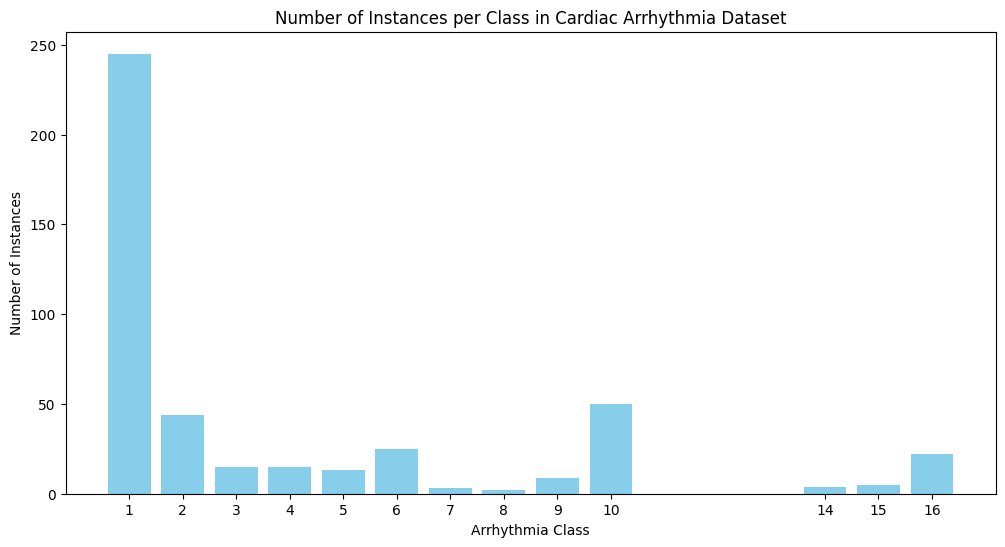

In [59]:
#visualization (bar plot) for class instances
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(class_counts.index.astype(int), class_counts.values, color='skyblue')
plt.xlabel("Arrhythmia Class")
plt.ylabel("Number of Instances")
plt.title("Number of Instances per Class in Cardiac Arrhythmia Dataset")
plt.xticks(class_counts.index.astype(int))
plt.show()

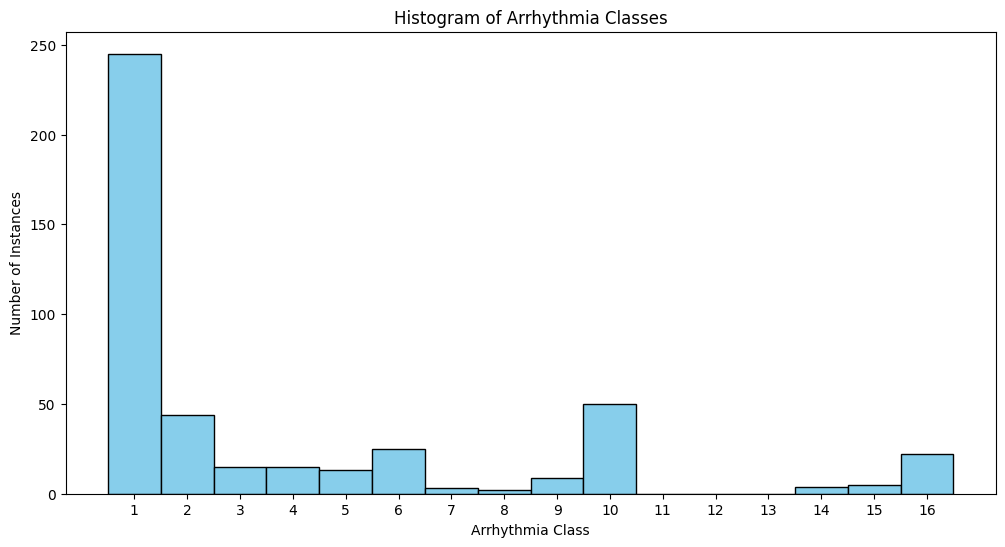

In [60]:
# Histogram for Class Distribution


class_col = new_df.columns[-1]  # last column
plt.figure(figsize=(12,6))
plt.hist(new_df[class_col], bins=range(1,18), edgecolor='black', color='skyblue', align='left')
plt.xlabel("Arrhythmia Class")
plt.ylabel("Number of Instances")
plt.title("Histogram of Arrhythmia Classes")
plt.xticks(range(1,17))
plt.show()

/tmp/ipython-input-1869508863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=class_col, data=new_df, palette="viridis")


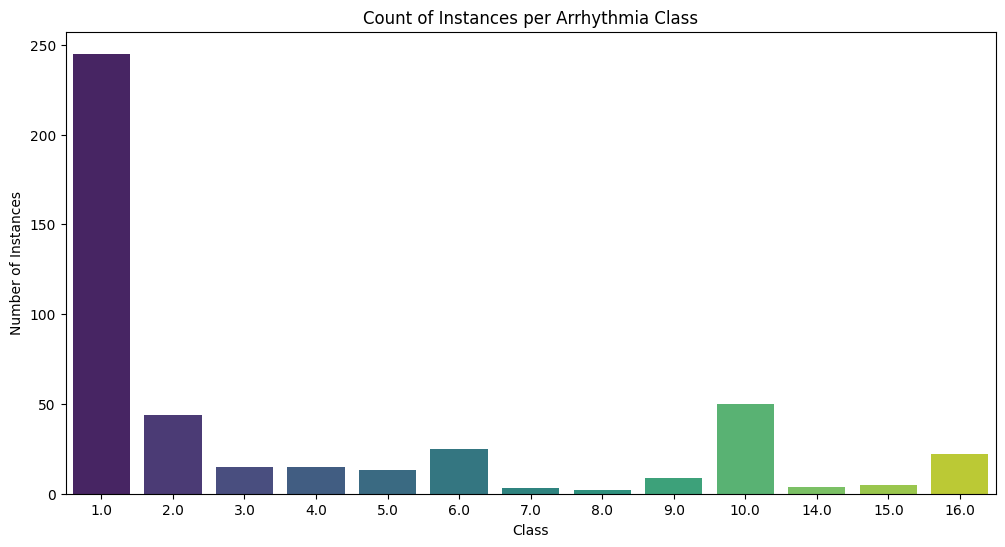

In [63]:
# Count Plot (bar chart) for Class Counts
plt.figure(figsize=(12,6))
sns.countplot(x=class_col, data=new_df, palette="viridis")
plt.title("Count of Instances per Arrhythmia Class")
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.show()

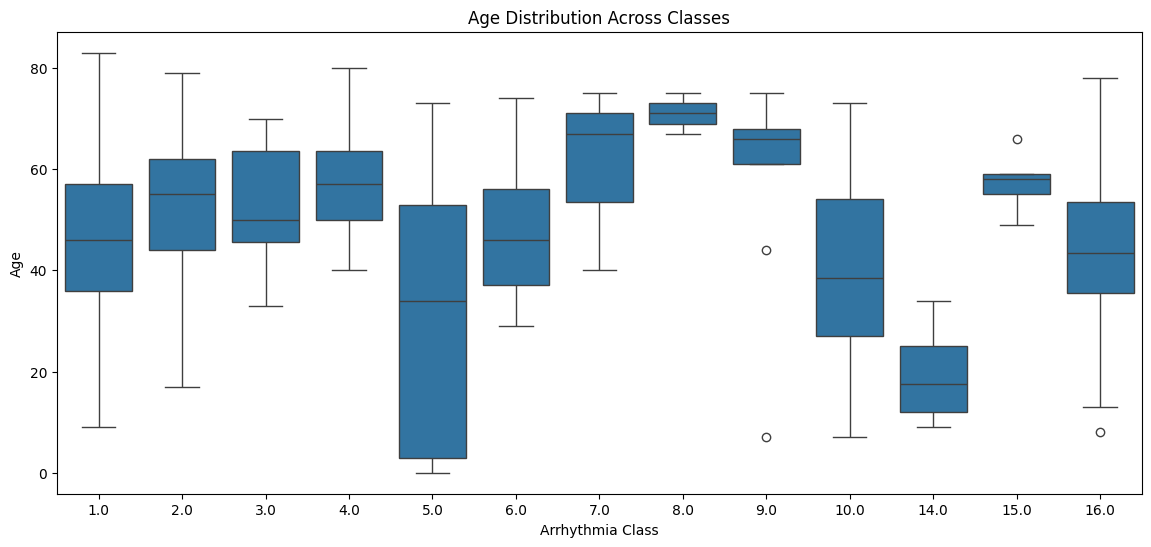

In [61]:
plt.figure(figsize=(14,6))
import seaborn as sns
sns.boxplot(x=class_col, y="Age", data=new_df)
plt.xlabel("Arrhythmia Class")
plt.ylabel("Age")
plt.title("Age Distribution Across Classes")
plt.show()

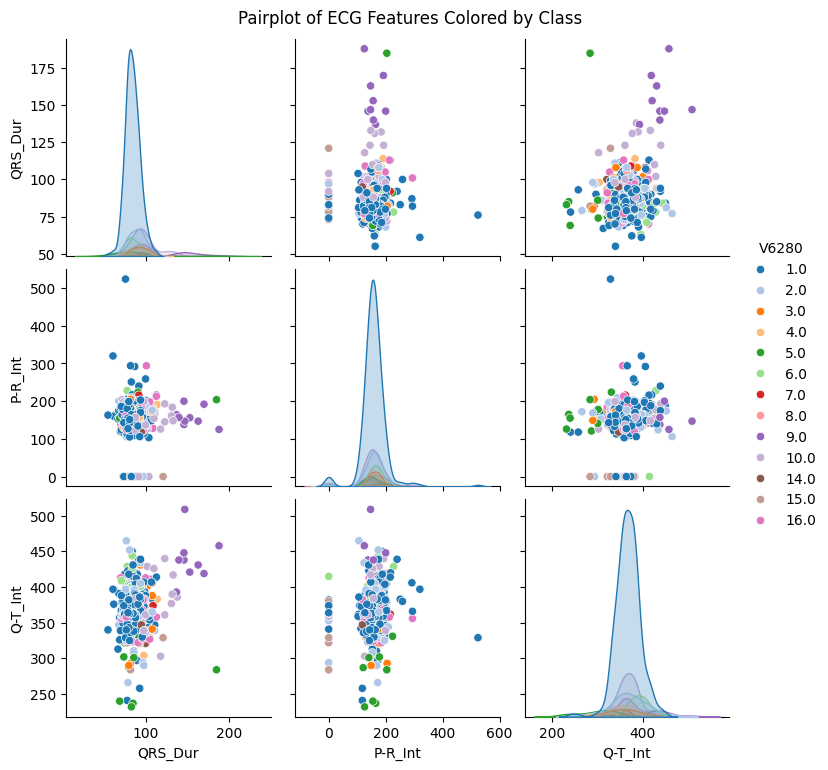

In [64]:
# feature separation among classes.
sns.pairplot(new_df, vars=["QRS_Dur","P-R_Int","Q-T_Int"], hue=class_col, palette="tab20")
plt.suptitle("Pairplot of ECG Features Colored by Class", y=1.02)
plt.show()

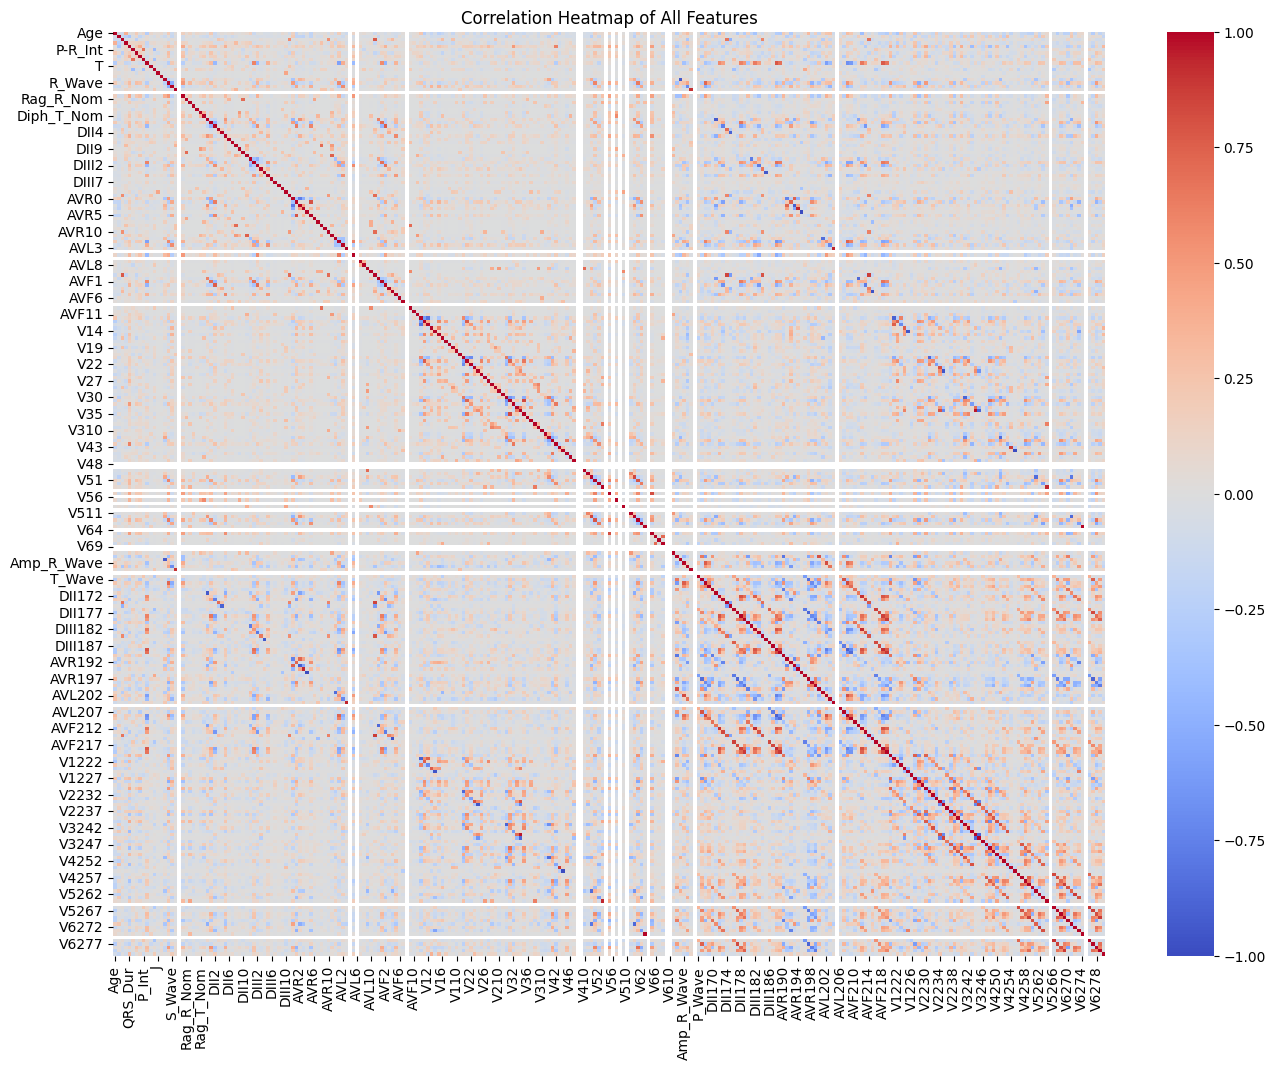

In [66]:
# Correlation Heatmap This shows which features are strongly correlated, helpful for feature selection.
plt.figure(figsize=(16,12))
corr = new_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of All Features")
plt.show()

## Handling Outliers

In [69]:
# outliers detectons
#  numeric features only
numeric_cols = new_df.select_dtypes(include=['float64','int64']).columns

# Function to detect outliers
def detect_outliers(df, cols):
    outliers = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    return outliers

outlier_counts = detect_outliers(new_df, numeric_cols)
# Sort columns by number of outliers
sorted_outliers = dict(sorted(outlier_counts.items(), key=lambda item: item[1], reverse=True))
sorted_outliers

{'AVF0': 112,
 'AVF211': 112,
 'DII0': 105,
 'DII171': 105,
 'V50': 101,
 'V5261': 101,
 'AVR0': 92,
 'V10': 89,
 'V1221': 89,
 'V11': 85,
 'AVR2': 74,
 'AVR193': 74,
 'V22': 55,
 'V61': 54,
 'DIII181': 54,
 'V40': 51,
 'V4251': 51,
 'V13': 48,
 'V1224': 48,
 'V5266': 45,
 'V6276': 45,
 'V15': 44,
 'V20': 43,
 'V21': 43,
 'V2231': 43,
 'V52': 42,
 'V32': 40,
 'T_Int': 39,
 'P_Wave': 39,
 'DIII180': 39,
 'AVL201': 39,
 'DIII183': 38,
 'AVR3': 37,
 'AVR194': 37,
 'DIII186': 35,
 'V2230': 35,
 'V6271': 35,
 'DIII3': 34,
 'DIII184': 34,
 'V4250': 34,
 'V1228': 33,
 'P_Int': 31,
 'AVF5': 31,
 'V23': 31,
 'V2234': 31,
 'V6280': 31,
 'V30': 29,
 'V35': 29,
 'V42': 29,
 'V2238': 29,
 'V3241': 29,
 'V6270': 29,
 'V31': 28,
 'T_Wave': 28,
 'AVF210': 28,
 'P-R_Int': 27,
 'JJ_Wave': 27,
 'AVL203': 27,
 'AVF213': 27,
 'AVF217': 27,
 'Q-T_Int': 26,
 'V2237': 25,
 'V5260': 25,
 'AVL0': 24,
 'V41': 24,
 'V1220': 24,
 'V1222': 24,
 'V3248': 24,
 'V4256': 24,
 'DII170': 23,
 'DII177': 23,
 'V3240': 23,


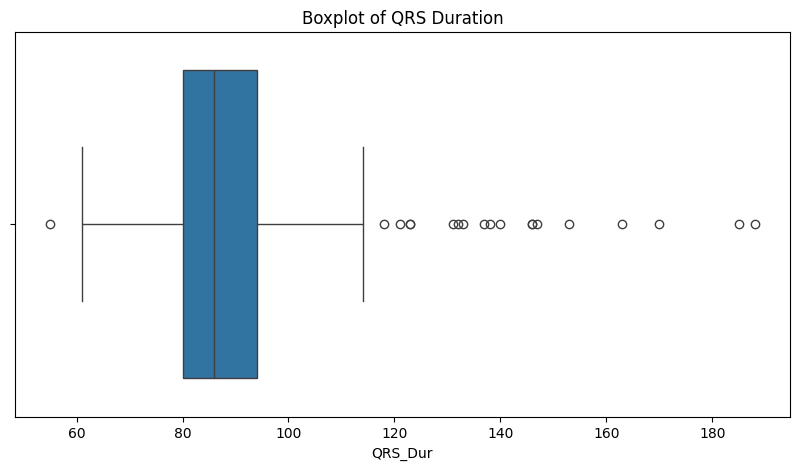

In [70]:
plt.figure(figsize=(10,5))
sns.boxplot(x=new_df["QRS_Dur"])
plt.title("Boxplot of QRS Duration")
plt.show()

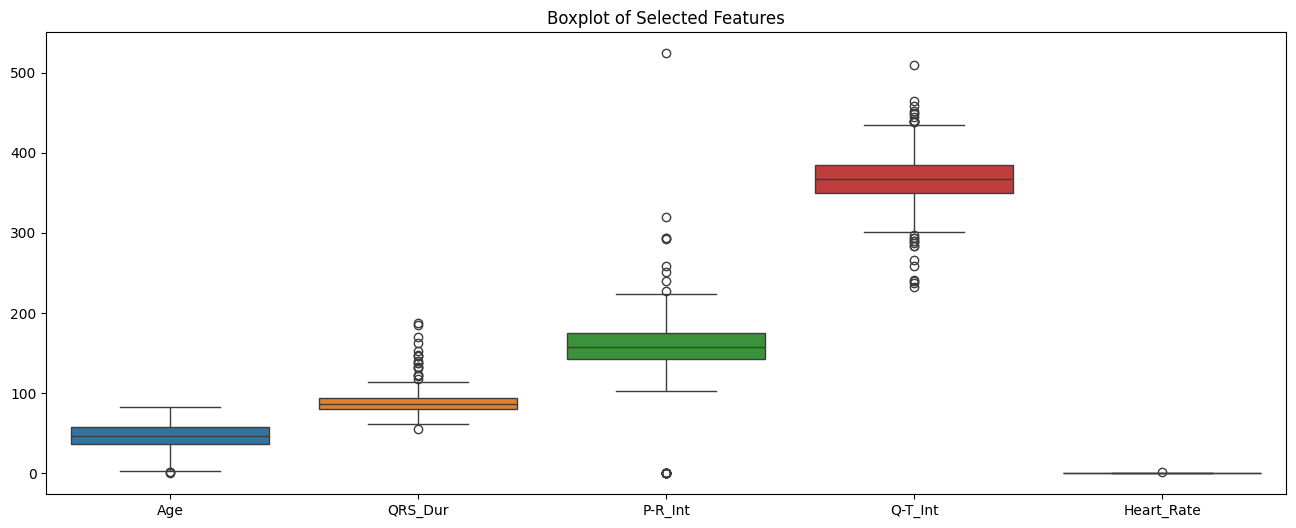

In [71]:
plt.figure(figsize=(16,6))
sns.boxplot(data=new_df[["Age","QRS_Dur","P-R_Int","Q-T_Int","Heart_Rate"]])
plt.title("Boxplot of Selected Features")
plt.show()

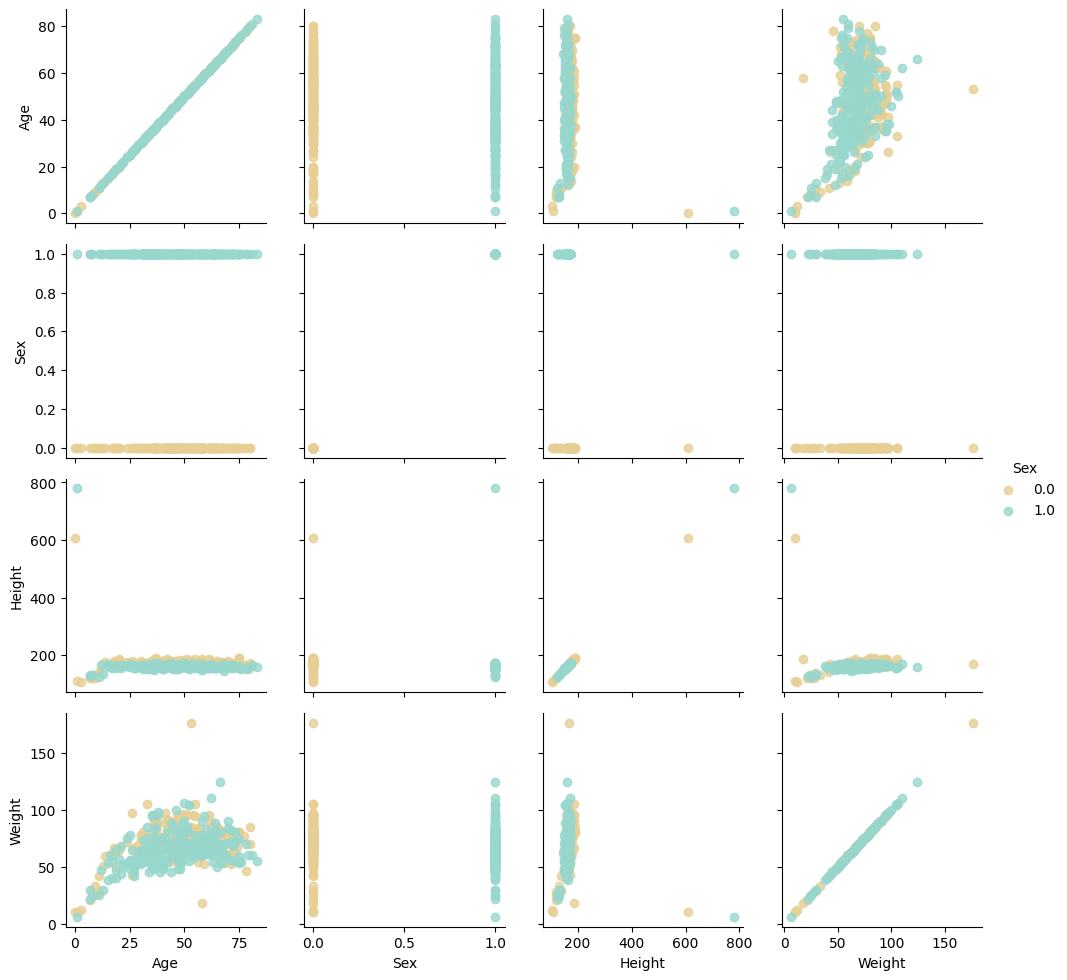

In [75]:
g = sns.PairGrid(final_df, vars=['Age', 'Sex', 'Height', 'Weight'],
                 hue='Sex', palette='BrBG')
g.map(plt.scatter, alpha=0.8)
g.add_legend()

# PairGrid creates a matrix of scatterplots for each pair of selected variables.

# hue='Sex' colors points by the Sex column (0 = male, 1 = female).

# alpha=0.8 makes points slightly transparent so overlaps are visible.
# spot outliers as isolated points.

In [76]:
# According to scatter plots, there are few outliers in 'height' and 'weight' attributes.
sorted(final_df['Height'], reverse=True)[:10]

[780.0, 608.0, 190.0, 190.0, 190.0, 188.0, 186.0, 186.0, 186.0, 185.0]

In [77]:
# The tallest person ever lived in the world was 272 cm (1940). His followers were 267 cm(1905)
# and 263.5 cm(1969). Replacing 780 and 608 with 180 and 108 cm respectively

In [78]:
final_df['Height']=final_df['Height'].replace(608,108)
final_df['Height']=final_df['Height'].replace(780,180)

In [79]:
sorted(final_df['Weight'], reverse=True)[:10]

[176.0, 124.0, 110.0, 106.0, 105.0, 105.0, 104.0, 104.0, 100.0, 98.0]

In [80]:
# 176 kgs is a possible weight. so we'll keep them in the dataframe.

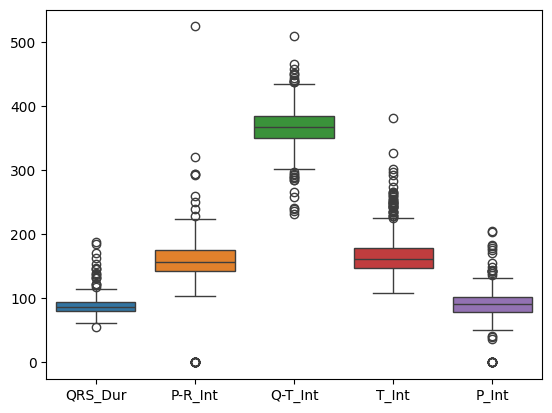

In [81]:
sns.boxplot(data=final_df[["QRS_Dur","P-R_Int","Q-T_Int","T_Int","P_Int"]]);

In [82]:
# PR interval is the period, measured in milliseconds, that extends from the beginning of the P wave until
# the beginning of the QRS complex; it is normally between 120 and 200ms in duration.

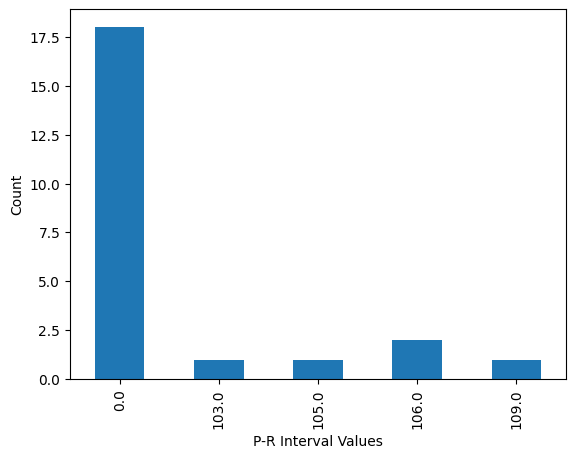

In [83]:
final_df['P-R_Int'].value_counts().sort_index().head().plot(kind='bar')
plt.xlabel('P-R Interval Values')
plt.ylabel('Count');

Text(0, 0.5, 'Count')

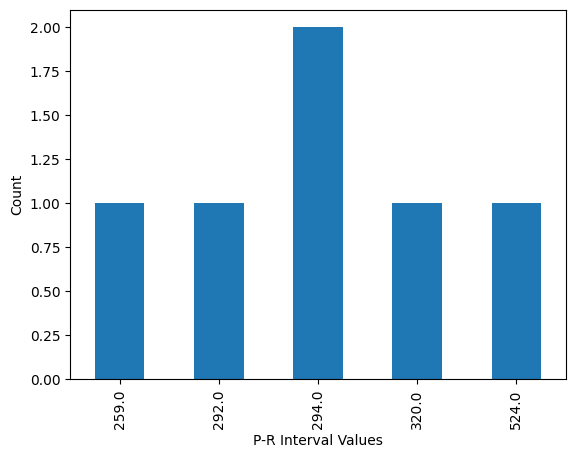

In [86]:
final_df['P-R_Int'].value_counts().sort_index().tail().plot(kind='bar')
plt.xlabel('P-R Interval Values')
plt.ylabel('Count')

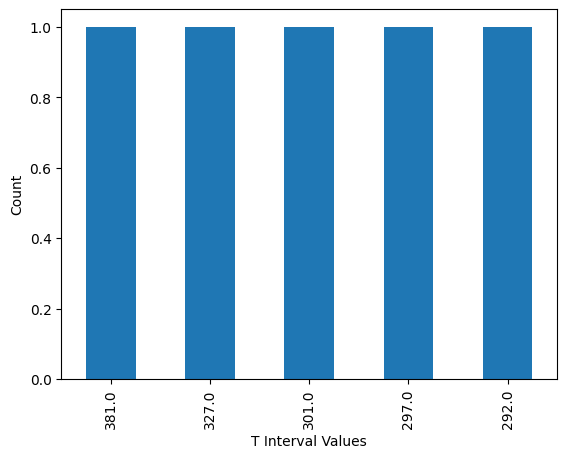

In [84]:
final_df['T_Int'].value_counts().sort_index(ascending=False).head().plot(kind='bar')
plt.xlabel('T Interval Values')
plt.ylabel('Count');

Text(0, 0.5, 'Count')

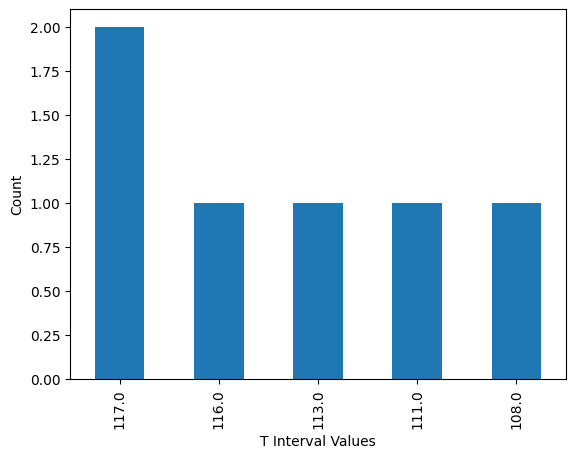

In [85]:
final_df['T_Int'].value_counts().sort_index(ascending=False).tail().plot(kind='bar')
plt.xlabel('T Interval Values')
plt.ylabel('Count')

In [ ]:
# # PR Interval data is including outliers 0(x18). I'll keep them
# # QT interval is a measure of the time between the start of the Q wave and the end of the T wave in the heart's electrical cycle.
# The outlier data appearing in Q-T Interval box might be related to the outlier of T-interval data.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 80.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 49.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 55.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 78.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 46.0% of the points cannot be plac

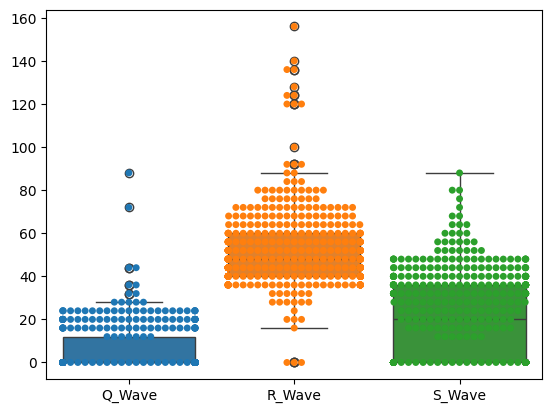

In [87]:
sns.boxplot(data=final_df[["Q_Wave","R_Wave","S_Wave"]])
sns.swarmplot(data=final_df[["Q_Wave","R_Wave","S_Wave"]])

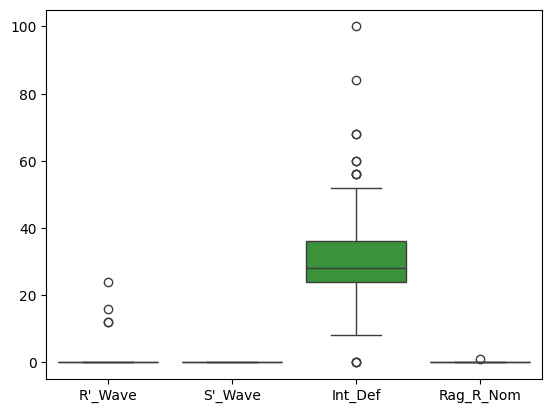

In [89]:
sns.boxplot(data=final_df[["R'_Wave","S'_Wave","Int_Def","Rag_R_Nom"]]);
#sns.swarmplot(data=final_df[["R'_Wave","S'_Wave","Int_Def","Rag_R_Nom"]])

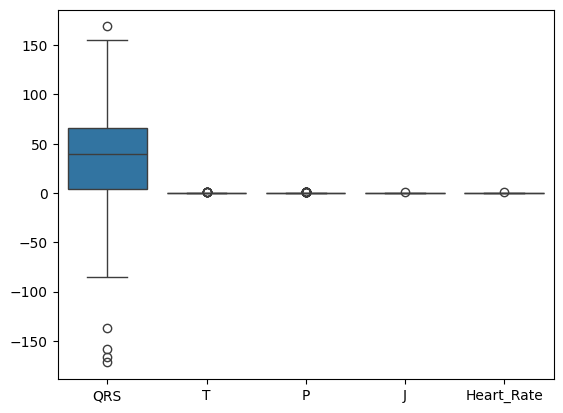

In [88]:
sns.boxplot(data=final_df[["QRS","T","P","J","Heart_Rate"]]);

In [ ]:
# S'Wave has 0's which is not a NaN. So, we can't assume it as including outliers.

In [90]:
final_df["R'_Wave"].value_counts().sort_index(ascending=False)

,count
R'_Wave,
24.0,1
16.0,1
12.0,2
0.0,448


In [91]:
final_df["S'_Wave"].value_counts().sort_index(ascending=False)

,count
S'_Wave,
0.0,452


In [92]:
final_df["Rag_R_Nom"].value_counts().sort_index(ascending=False)

,count
Rag_R_Nom,
1.0,1
0.0,451


In [93]:
final_df["Diph_R_Nom"].value_counts().sort_index(ascending=False)

,count
Diph_R_Nom,
1.0,5
0.0,447


In [94]:
final_df["Rag_P_Nom"].value_counts().sort_index(ascending=False)

,count
Rag_P_Nom,
1.0,5
0.0,447


In [95]:
final_df["Diph_P_Nom"].value_counts().sort_index(ascending=False)

,count
Diph_P_Nom,
1.0,2
0.0,450


In [96]:
final_df["Rag_T_Nom"].value_counts().sort_index(ascending=False)

,count
Rag_T_Nom,
1.0,2
0.0,450


In [97]:
final_df["Diph_T_Nom"].value_counts().sort_index(ascending=False)

,count
Diph_T_Nom,
1.0,4
0.0,448


<Axes: >

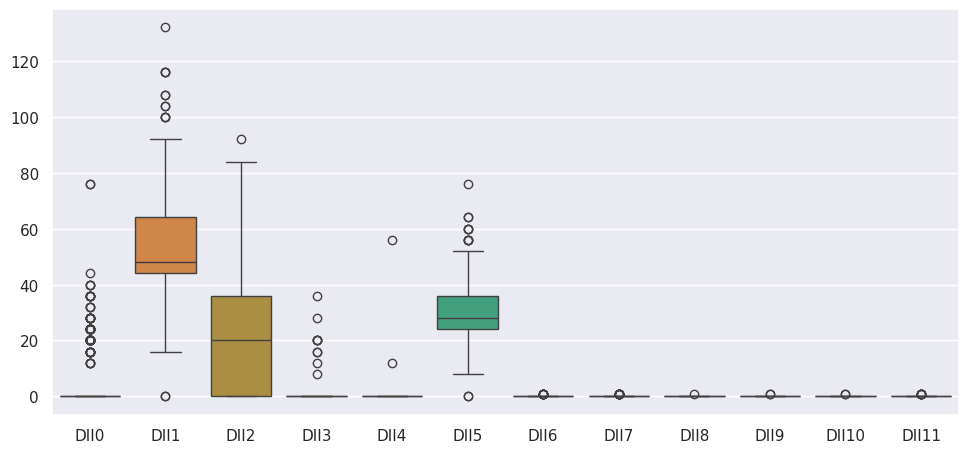

In [99]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["DII0", "DII1","DII2", "DII3", "DII4","DII5","DII6","DII7","DII8","DII9","DII10","DII11"]])

<Axes: >

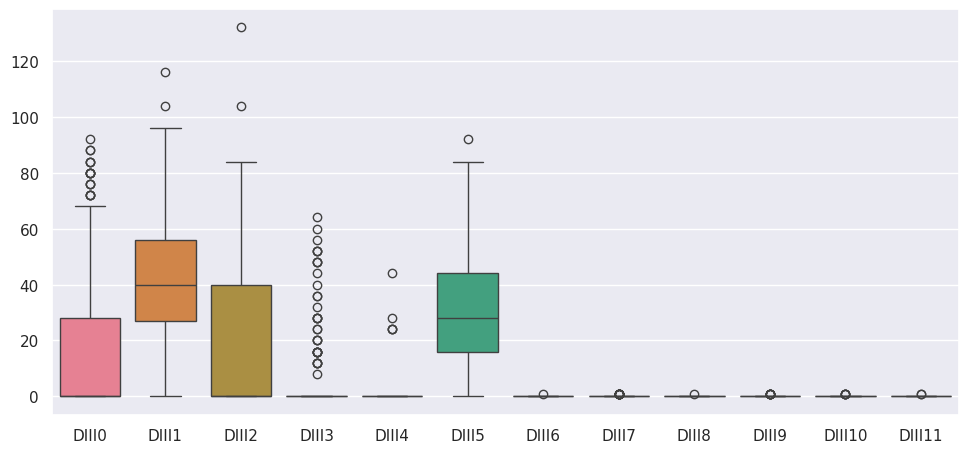

In [101]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["DIII0","DIII1","DIII2", "DIII3", "DIII4","DIII5","DIII6",
                       "DIII7","DIII8","DIII9","DIII10","DIII11"]])

<Axes: >

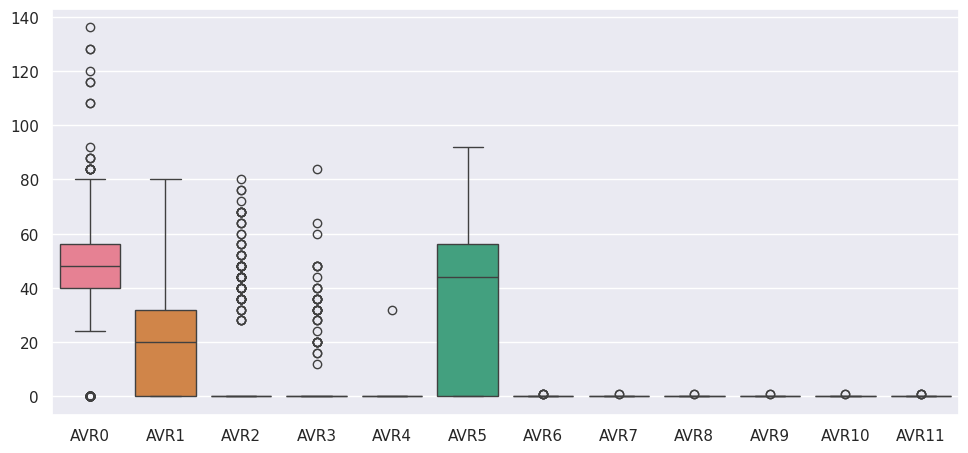

In [103]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["AVR0","AVR1","AVR2","AVR3","AVR4","AVR5",
                       "AVR6","AVR7","AVR8","AVR9","AVR10","AVR11"]])

<Axes: >

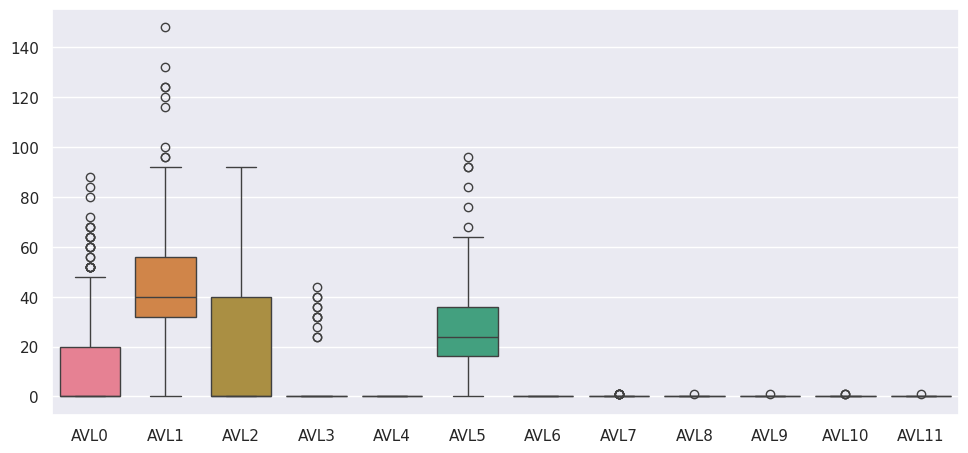

In [105]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["AVL0","AVL1","AVL2","AVL3","AVL4","AVL5","AVL6","AVL7","AVL8","AVL9","AVL10","AVL11"]])

<Axes: >

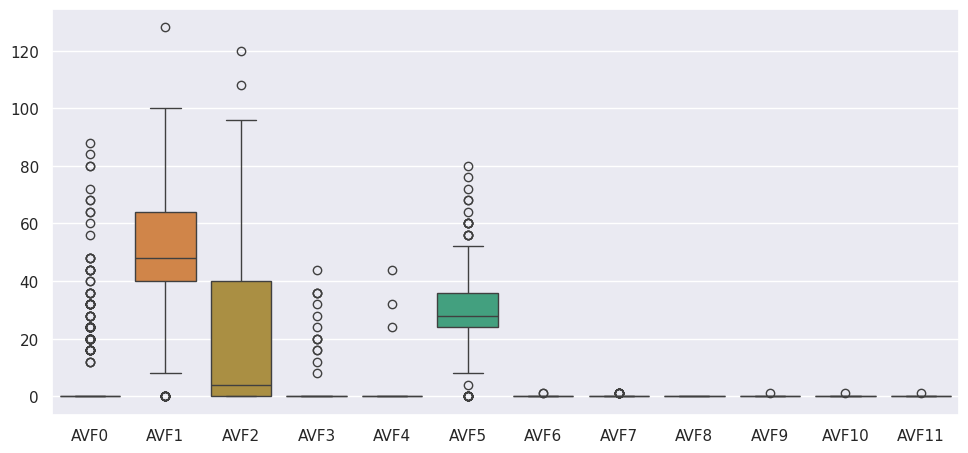

In [107]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["AVF0","AVF1","AVF2","AVF3","AVF4","AVF5","AVF6","AVF7","AVF8","AVF9","AVF10","AVF11"]])

<Axes: >

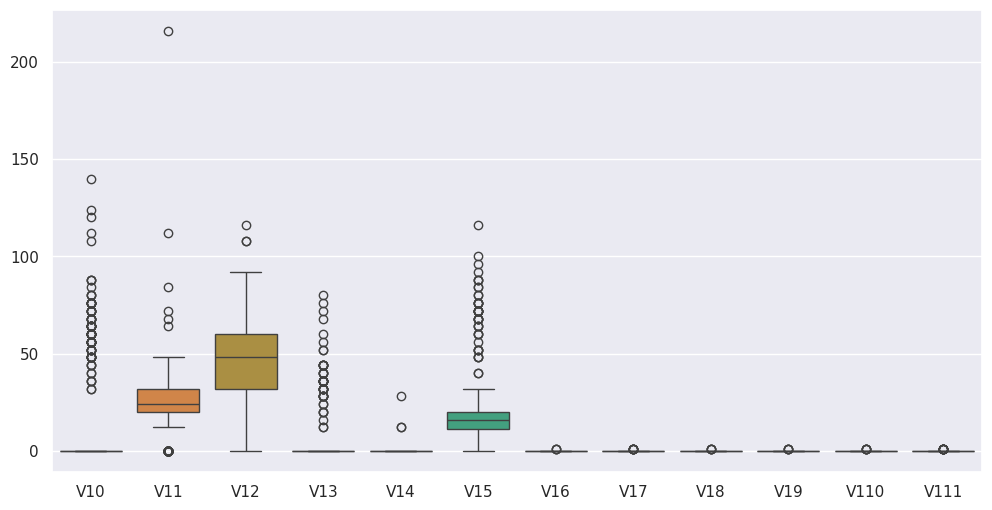

In [109]:
sns.set(rc={'figure.figsize':(12,6)})
sns.boxplot(data=final_df[["V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V110","V111"]])

In [111]:
final_df["V10"].value_counts().sort_index(ascending=False)

,count
V10,
140.0,1
124.0,1
120.0,1
112.0,1
108.0,1
88.0,3
84.0,1
80.0,3
76.0,8


V10 has an outlier, but when we look at other sets (V20, V30, V50) we can see that there's a similar outlier. Since our data is heavily biased, I can't say these outliers should be dropped.

For example, when we look at our data, we can see that class # 8 (Supraventricular Premature Contraction) has only 2 instances. Or # 3 (Ventricular Premature Contraction (PVC)) has only 3. The outliers appearing in our plots might belong to these instances and need to be kept.

## Understanding whether people's age affects their condition

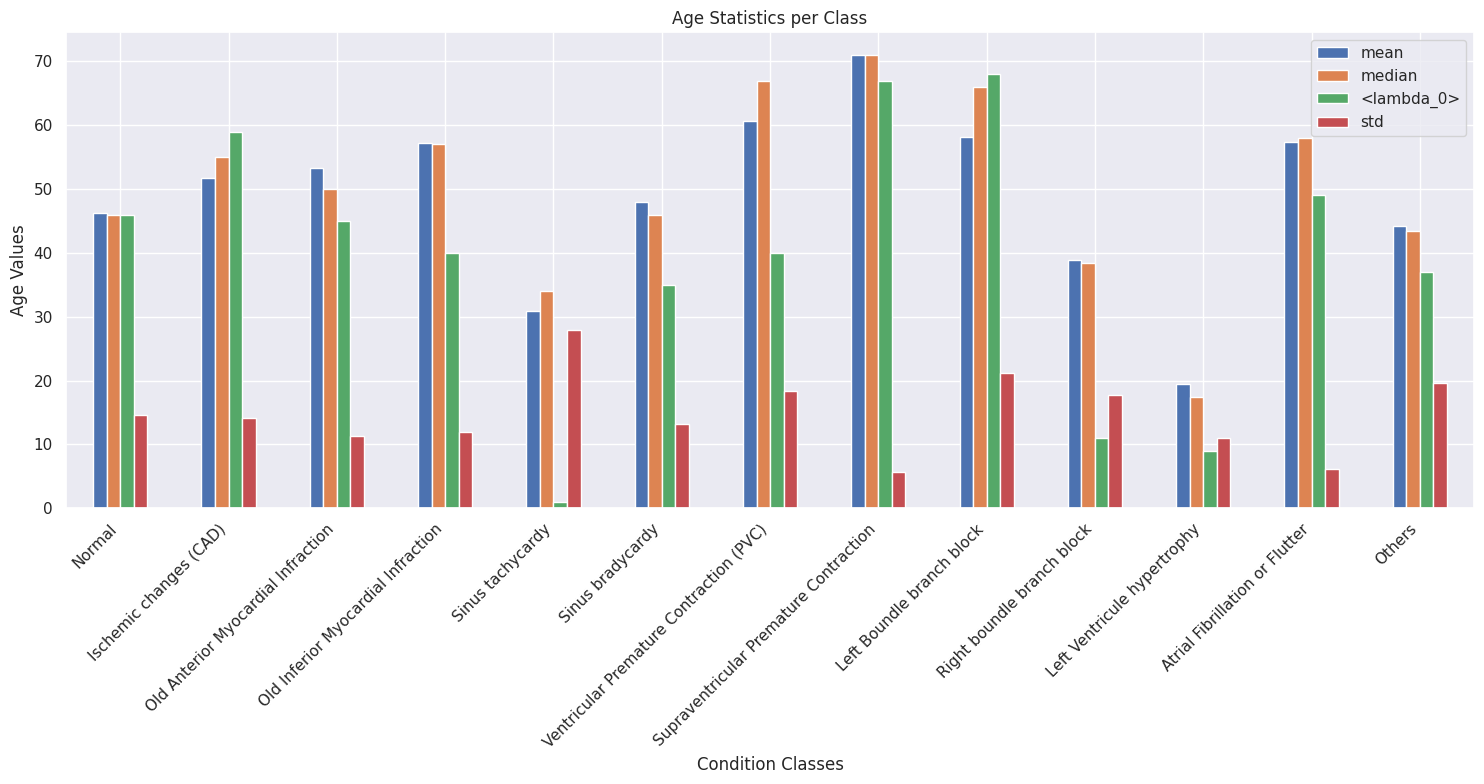

,Class_ID,mean,median,<lambda_0>,std,Class_Name
0,1.0,46.273469,46.0,46.0,14.556092,Normal
1,2.0,51.750000,55.0,59.0,14.160418,Ischemic changes (CAD)
2,3.0,53.333333,50.0,45.0,11.286317,Old Anterior Myocardial Infraction
3,4.0,57.266667,57.0,40.0,11.895177,Old Inferior Myocardial Infraction
4,5.0,30.846154,34.0,1.0,27.904140,Sinus tachycardy
5,6.0,47.920000,46.0,35.0,13.165359,Sinus bradycardy
6,7.0,60.666667,67.0,40.0,18.339393,Ventricular Premature Contraction (PVC)
7,8.0,71.000000,71.0,67.0,5.656854,Supraventricular Premature Contraction
8,9.0,58.222222,66.0,68.0,21.211894,Left Boundle branch block
9,10.0,38.920000,38.5,11.0,17.692198,Right boundle branch block


In [114]:
# Exclude the unwanted classes
excluded_classes = ["1.Degree AtrioVentricular block", "2.Degree AV block", "3.Degree AV block"]

# Filter class names
filtered_class_names = [c for c in class_names if c not in excluded_classes]

# Group by the correct class column (class_col is 'V6280') and calculate stats
age_stats = new_df.groupby(class_col)['Age'].agg(['mean', 'median', lambda x: x.mode()[0], 'std']).reset_index()

# Rename the class column for clarity
age_stats.rename(columns={class_col: 'Class_ID'}, inplace=True)

# Create a mapping from Class_ID to descriptive names
# class_names list is 0-indexed, while Class_ID is 1-indexed
class_id_to_name_map = {i+1: name for i, name in enumerate(class_names)}

age_stats['Class_Name'] = age_stats['Class_ID'].map(class_id_to_name_map)

# Keep only filtered classes based on their names
age_stats = age_stats[age_stats['Class_Name'].isin(filtered_class_names)]

# Plot
fig, ax = plt.subplots(figsize=(15,8))
age_stats.set_index('Class_Name')[['mean','median','<lambda_0>','std']].plot(kind='bar', ax=ax)
ax.set_title("Age Statistics per Class")
ax.set_ylabel("Age Values")
ax.set_xlabel("Condition Classes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# The DataFrame
age_stats

##  whether  gender affects  condition
Converts numeric sex to readable labels (Male/Female).

Groups data by class and counts males/females.

Maps class IDs to descriptive names.

Plots a stacked bar chart showing gender distribution per class.

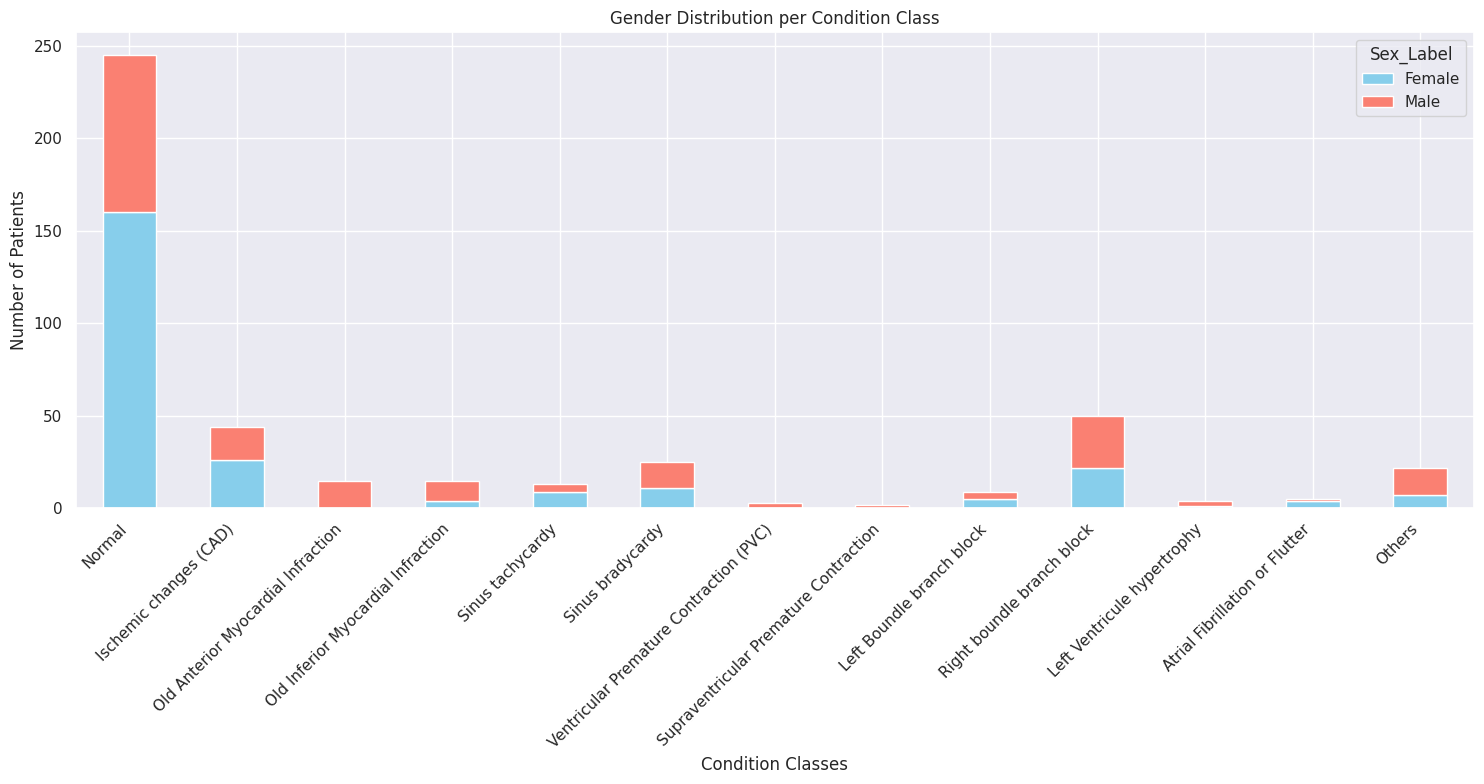

Sex_Label,Female,Male
V6280,,
Normal,160,85
Ischemic changes (CAD),26,18
Old Anterior Myocardial Infraction,0,15
Old Inferior Myocardial Infraction,4,11
Sinus tachycardy,9,4
Sinus bradycardy,11,14
Ventricular Premature Contraction (PVC),0,3
Supraventricular Premature Contraction,0,2
Left Boundle branch block,5,4


In [115]:
# Map Sex to readable labels
sex_map = {0: 'Male', 1: 'Female'}
new_df['Sex_Label'] = new_df['Sex'].map(sex_map)

# Group by class column and Sex, count occurrences
gender_counts = new_df.groupby([class_col, 'Sex_Label']).size().unstack(fill_value=0)

# Map Class_ID to descriptive names
gender_counts.index = gender_counts.index.map(class_id_to_name_map)

# Keep only filtered classes
gender_counts = gender_counts.loc[filtered_class_names]

# Plot stacked bar chart for male/female distribution per class
fig, ax = plt.subplots(figsize=(15,8))
gender_counts.plot(kind='bar', stacked=True, ax=ax, color=['skyblue','salmon'])
ax.set_title("Gender Distribution per Condition Class")
ax.set_ylabel("Number of Patients")
ax.set_xlabel("Condition Classes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# The DataFrame
gender_counts

analysis for Weight

1-Groups the dataset by class.
2-Calculates mean, median, mode, and standard deviation for Weight.
3- Maps class IDs to readable names.
4- Excludes unwanted classes.
5- Plots a bar chart showing Weight stats per class.

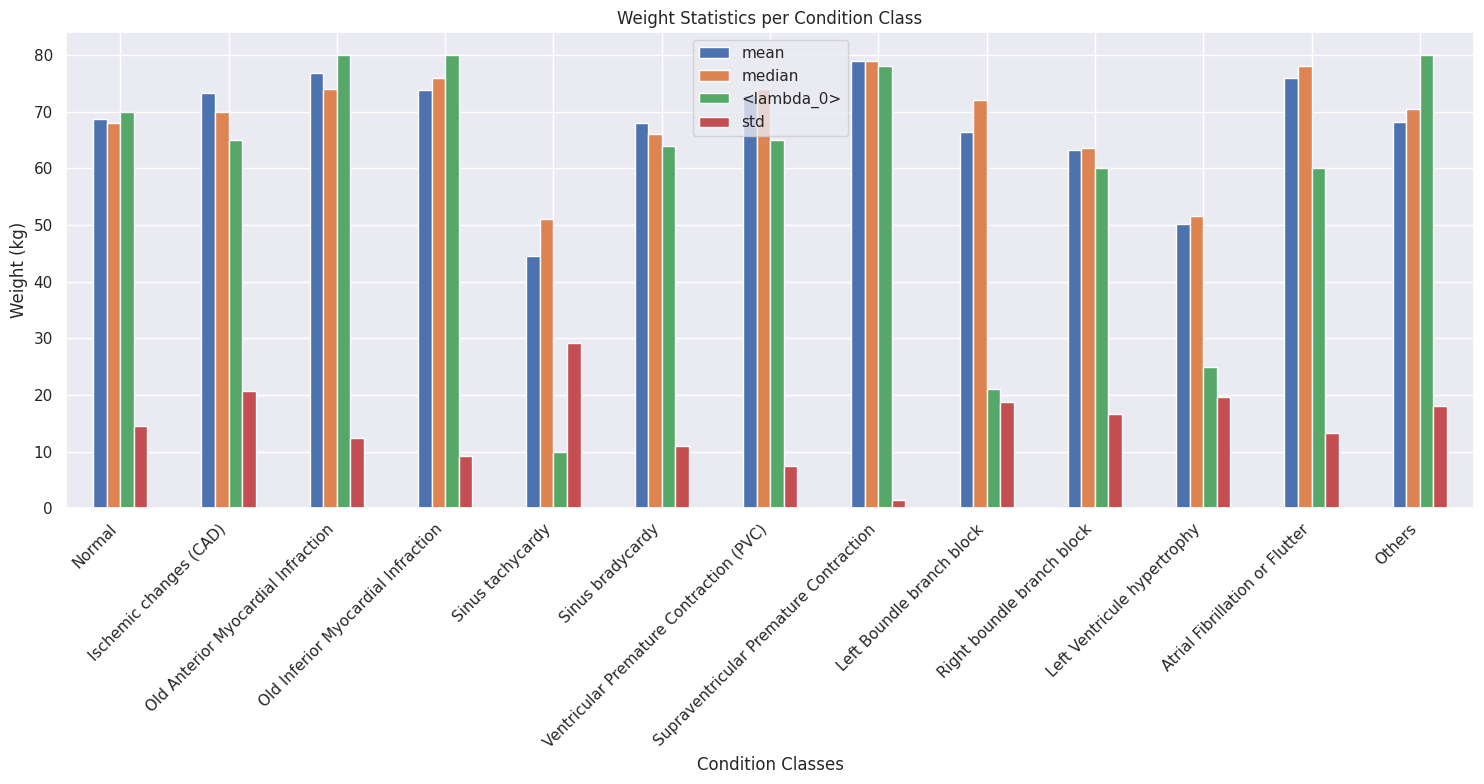

,Class_ID,mean,median,<lambda_0>,std,Class_Name
0,1.0,68.669388,68.0,70.0,14.454595,Normal
1,2.0,73.363636,70.0,65.0,20.617323,Ischemic changes (CAD)
2,3.0,76.866667,74.0,80.0,12.397388,Old Anterior Myocardial Infraction
3,4.0,73.866667,76.0,80.0,9.318696,Old Inferior Myocardial Infraction
4,5.0,44.615385,51.0,10.0,29.259011,Sinus tachycardy
5,6.0,68.000000,66.0,64.0,11.045361,Sinus bradycardy
6,7.0,73.000000,74.0,65.0,7.549834,Ventricular Premature Contraction (PVC)
7,8.0,79.000000,79.0,78.0,1.414214,Supraventricular Premature Contraction
8,9.0,66.444444,72.0,21.0,18.808981,Left Boundle branch block
9,10.0,63.300000,63.5,60.0,16.579124,Right boundle branch block


In [116]:
# Group by the class column and calculate weight statistics
weight_stats = new_df.groupby(class_col)['Weight'].agg([
    'mean',
    'median',
    lambda x: x.mode()[0],  # Mode
    'std'
]).reset_index()

# Rename class column
weight_stats.rename(columns={class_col: 'Class_ID'}, inplace=True)

# Map Class_ID to descriptive names
weight_stats['Class_Name'] = weight_stats['Class_ID'].map(class_id_to_name_map)

# Keep only filtered classes
weight_stats = weight_stats[weight_stats['Class_Name'].isin(filtered_class_names)]

# Plot
fig, ax = plt.subplots(figsize=(15,8))
weight_stats.set_index('Class_Name')[['mean','median','<lambda_0>','std']].plot(kind='bar', ax=ax)
ax.set_title("Weight Statistics per Condition Class")
ax.set_ylabel("Weight (kg)")
ax.set_xlabel("Condition Classes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Show the DataFrame
weight_stats

whether QRS Duration affects people condition

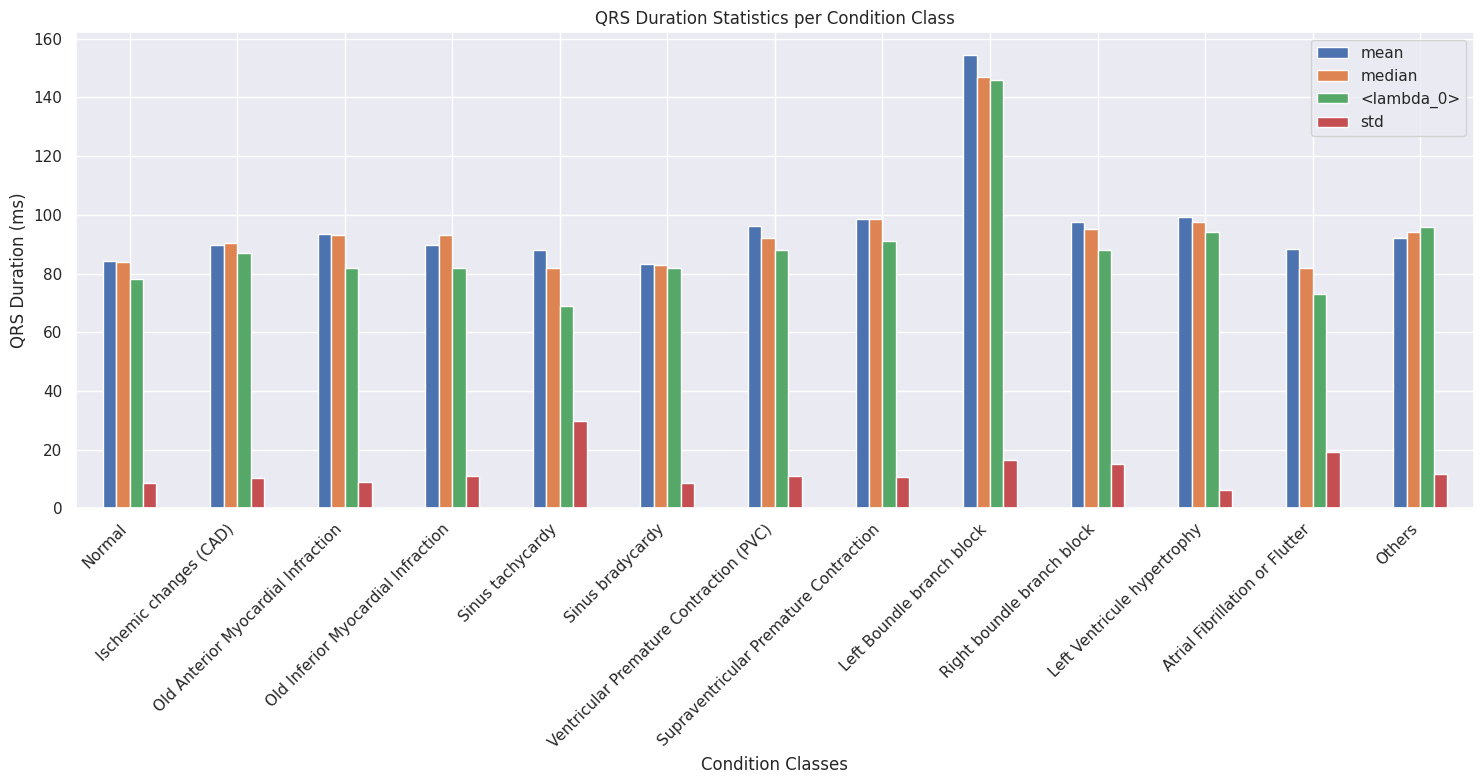

,Class_ID,mean,median,<lambda_0>,std,Class_Name
0,1.0,84.277551,84.0,78.0,8.735439,Normal
1,2.0,89.818182,90.5,87.0,10.207778,Ischemic changes (CAD)
2,3.0,93.333333,93.0,82.0,9.131317,Old Anterior Myocardial Infraction
3,4.0,89.866667,93.0,82.0,10.979635,Old Inferior Myocardial Infraction
4,5.0,88.000000,82.0,69.0,29.796532,Sinus tachycardy
5,6.0,83.160000,83.0,82.0,8.561931,Sinus bradycardy
6,7.0,96.333333,92.0,88.0,11.150486,Ventricular Premature Contraction (PVC)
7,8.0,98.500000,98.5,91.0,10.606602,Supraventricular Premature Contraction
8,9.0,154.444444,147.0,146.0,16.409685,Left Boundle branch block
9,10.0,97.580000,95.0,88.0,15.129495,Right boundle branch block


In [117]:
# Group by class column and calculate QRS Duration statistics
qrs_stats = new_df.groupby(class_col)['QRS_Dur'].agg([
    'mean',
    'median',
    lambda x: x.mode()[0],  # Mode
    'std'
]).reset_index()

# Rename class column
qrs_stats.rename(columns={class_col: 'Class_ID'}, inplace=True)

# Map Class_ID to descriptive names
qrs_stats['Class_Name'] = qrs_stats['Class_ID'].map(class_id_to_name_map)

# Keep only filtered classes (exclude unwanted AV blocks)
qrs_stats = qrs_stats[qrs_stats['Class_Name'].isin(filtered_class_names)]

# Plot
fig, ax = plt.subplots(figsize=(15,8))
qrs_stats.set_index('Class_Name')[['mean','median','<lambda_0>','std']].plot(kind='bar', ax=ax)
ax.set_title("QRS Duration Statistics per Condition Class")
ax.set_ylabel("QRS Duration (ms)")
ax.set_xlabel("Condition Classes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the DataFrame
qrs_stats

In [118]:

final_df.head()

,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6270,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279
0,75.0,0.0,190.0,80.0,91.0,193.0,371.0,174.0,121.0,-16.0,...,-0.3,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4
1,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,-0.5,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8
2,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.9,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0
3,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.1,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6
4,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,-0.4,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8
